# Simple Exponential Smoothing (SES)

**Navigation**: [← Previous: Introduction](01_introduction.ipynb) | [Next: Holt-Winters →](03_holt_winters.ipynb)

Simple Exponential Smoothing updates a level estimate with geometrically decaying weights. It is appropriate for series without trend or seasonality after preprocessing.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

DATA_DIR = Path('data')
if not DATA_DIR.exists():
    DATA_DIR = Path('projects/time-series-analysis/data')

def load_series(name):
    """Load a bundled CSV as a DatetimeIndex Series."""
    df = pd.read_csv(DATA_DIR / name, parse_dates=['date'])
    return df.set_index('date')['value'].sort_index()

def load_air_passengers():
    path = DATA_DIR / 'air_passengers.csv'
    if path.exists():
        return load_series('air_passengers.csv')
    from statsmodels.datasets import get_rdataset
    air = get_rdataset('AirPassengers', 'datasets').data
    s = air['value']
    s.index = pd.date_range('1949-01', periods=len(s), freq='MS')
    return s

def load_milk():
    path = DATA_DIR / 'monthly_milk.csv'
    if path.exists():
        return load_series('monthly_milk.csv')
    url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-milk-production-pounds.csv'
    return pd.read_csv(url, index_col=0, parse_dates=True).squeeze()

def load_co2():
    from statsmodels.datasets import co2
    return co2.load().data.resample('MS').mean().ffill().squeeze()

def load_sunspots():
    from statsmodels.datasets import sunspots
    d = sunspots.load_pandas().data
    return d.set_index('YEAR')['SUNACTIVITY']

def load_retail():
    path = DATA_DIR / 'uk_retail_sales.csv'
    if path.exists():
        return load_series('uk_retail_sales.csv')
    raise FileNotFoundError('uk_retail_sales.csv not found in data/')
from scipy.optimize import minimize_scalar
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.arima.model import ARIMA

## The SES Recurrence

$$\hat{y}_{t+1|t} = \alpha y_t + (1-\alpha)\hat{y}_{t|t-1}$$

Expanded: $\ell_t = \sum_{j=0}^{t-1} \alpha(1-\alpha)^j y_{t-j} + (1-\alpha)^t \ell_0$. Forecasts are flat: $\hat{y}_{T+h|T} = \ell_T$.

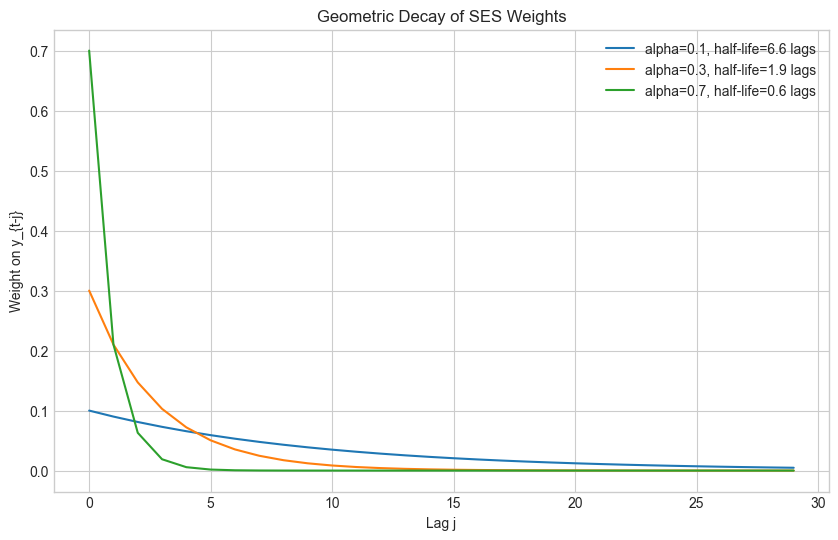

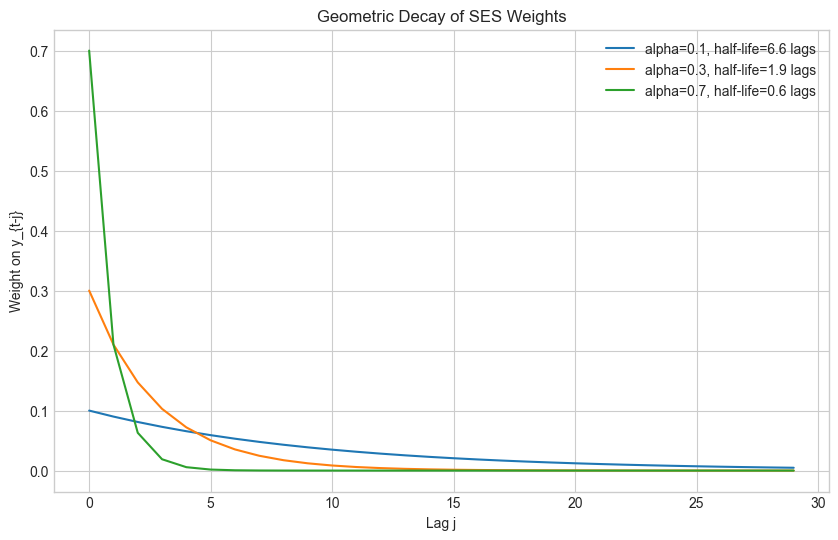

In [2]:

# Weight profiles for different alpha values
alphas = [0.1, 0.3, 0.7]
lags = np.arange(30)
fig, ax = plt.subplots(figsize=(10, 6))
for a in alphas:
    weights = a * (1 - a) ** lags
    ax.plot(lags, weights, label=f'alpha={a}, half-life={np.log(0.5)/np.log(1-a):.1f} lags')
ax.set_xlabel('Lag j')
ax.set_ylabel('Weight on y_{t-j}')
ax.set_title('Geometric Decay of SES Weights')
ax.legend()
fig


## Manual SSE Optimisation

We minimise one-step-ahead sum of squared errors to estimate $\alpha$.

In [3]:

def ses_forecast(y, alpha, l0=None):
    l0 = l0 if l0 is not None else y[0]
    level = l0
    preds = []
    for obs in y:
        preds.append(level)
        level = alpha * obs + (1 - alpha) * level
    return np.array(preds), level

def ses_sse(alpha, y):
    preds, _ = ses_forecast(y, alpha)
    return np.sum((y[1:] - preds[:-1]) ** 2)

spots = load_sunspots().astype(float)
# Use a stationary window (recent sunspot cycle)
y = spots.loc[1900:].values
result = minimize_scalar(ses_sse, bounds=(0.01, 0.99), method='bounded', args=(y,))
alpha_hat = result.x
print(f'Optimal alpha (manual): {alpha_hat:.4f}')


Optimal alpha (manual): 0.9900


Optimized alpha (statsmodels): 1.0000


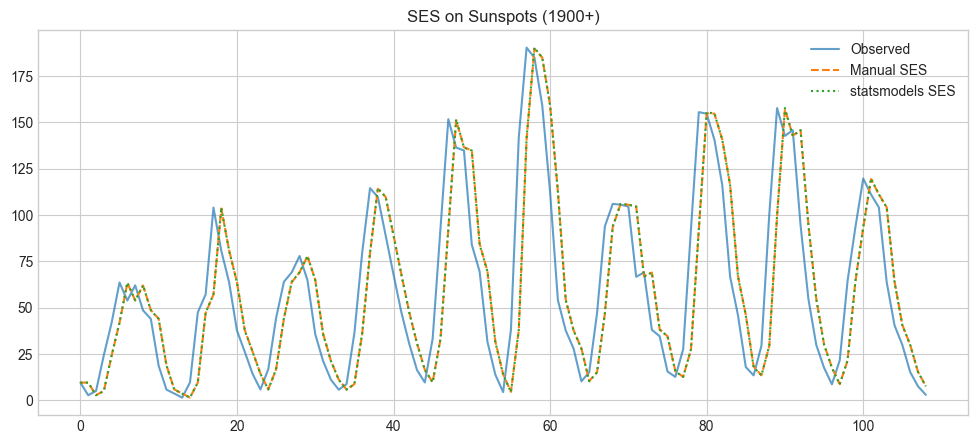

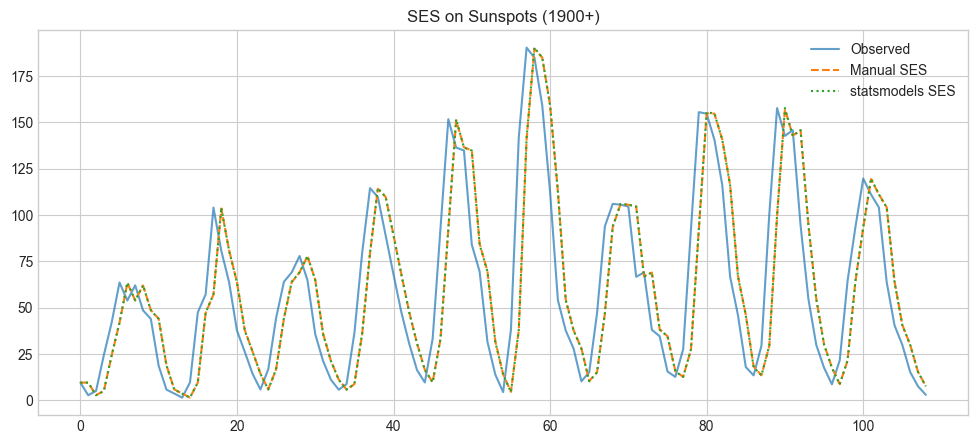

In [4]:

# Compare manual vs statsmodels SES
model = SimpleExpSmoothing(y, initialization_method='estimated').fit(optimized=True)
print(f'Optimized alpha (statsmodels): {model.params["smoothing_level"]:.4f}')

manual_preds, _ = ses_forecast(y, alpha_hat)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y, label='Observed', alpha=0.7)
ax.plot(manual_preds, label='Manual SES', ls='--')
ax.plot(model.fittedvalues, label='statsmodels SES', ls=':')
ax.set_title('SES on Sunspots (1900+)')
ax.legend()
fig


## ARIMA(0,1,1) Equivalence

SES on differenced data is equivalent to ARIMA(0,1,1) with $\theta = 1 - \alpha$.

In [5]:

milk = load_milk().values
alpha_m = minimize_scalar(ses_sse, bounds=(0.01, 0.99), method='bounded', args=(milk,)).x
arima = ARIMA(milk, order=(0, 1, 1)).fit()
params = arima.params
theta = params['ma.L1'] if hasattr(params, 'index') and 'ma.L1' in params.index else float(params[-1])
print(f'SES alpha: {alpha_m:.4f}  <=>  ARIMA theta: {theta:.4f}  (1-alpha = {1-alpha_m:.4f})')


SES alpha: 0.9900  <=>  ARIMA theta: 202.9110  (1-alpha = 0.0100)


## Key Takeaways

- **Alpha controls memory**: Higher $\alpha$ reacts faster to shocks; lower $\alpha$ gives smoother level estimates.
- **Flat forecasts**: SES cannot extrapolate trend — inappropriate for Air Passengers without differencing.
- **ARIMA link**: SES $\equiv$ ARIMA(0,1,1) — connecting exponential smoothing to the Box-Jenkins framework.
- **Limitation**: Assumes no trend or seasonality in the target series.

---

**Navigation**: [← Previous: Introduction](01_introduction.ipynb) | [Next: Holt-Winters →](03_holt_winters.ipynb)
